# Sea Surface Temperature and El Niño from HadISST

```{image} ../../thumbnails/gdex_logo.png
:alt: GDEX Cookbook logo
:width: 200px
```

---

## Overview

HadISST is the Met Office Hadley Centre's globally complete reconstruction of
monthly sea surface temperature (SST) and sea ice, spanning 1870–present on a 1°
grid. GDEX hosts it as dataset [`d277003`](https://gdex.ucar.edu/datasets/d277003/).

We use it to track the **El Niño–Southern Oscillation (ENSO)** by computing the
standard **Niño SST indices** — area-averaged anomalies over four regions of the
equatorial Pacific (Niño 1+2, 3, 3.4, and 4).

1. Access HadISST over OSDF
2. Prepare the SST field (mask land, standardize longitudes)
3. Compute area-weighted SST anomalies for the four Niño regions
4. Visualize El Niño and La Niña events across the regions

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [xarray](https://docs.xarray.dev) | Necessary | Labeled N-D arrays |
| [OSDF Cookbook](https://projectpythia.org/osdf-cookbook/) | Helpful | Streaming data over OSDF |
| [Niño regions / ONI](https://www.ncei.noaa.gov/access/monitoring/enso/sst) | Helpful | ENSO index background |

- **Time to learn**: 25 minutes

---

## Imports 

In [1]:
import gzip
import tempfile

import requests
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

## Accessing HadISST

HadISST is distributed as a single gzip-compressed NetCDF file. We stream it from
GDEX over the OSDF director, decompress it in memory, and open it with xarray.

In [2]:
url = "https://osdf-director.osg-htc.org/ncar/gdex/d277003/HadISST_sst.nc.gz"

response = requests.get(url)
response.raise_for_status()
raw = gzip.decompress(response.content)

with tempfile.NamedTemporaryFile(suffix=".nc") as tmp:
    tmp.write(raw)
    tmp.flush()
    ds = xr.open_dataset(tmp.name, engine="scipy", decode_times=False)

ds = xr.decode_cf(ds)
ds

<xarray.Dataset> Size: 486MB
Dimensions:    (time: 1876, nv: 2, latitude: 180, longitude: 360)
Coordinates:
  * time       (time) datetime64[ns] 15kB 1870-01-16T11:59:59.505615234 ... 2...
  * latitude   (latitude) float32 720B 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * longitude  (longitude) float32 1kB -179.5 -178.5 -177.5 ... 178.5 179.5
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) float32 15kB ...
    sst        (time, latitude, longitude) float32 486MB ...
Attributes:
    Title:                      Monthly version of HadISST sea surface temper...
    description:                HadISST 1.1 monthly average sea surface tempe...
    institution:                Met Office Hadley Centre
    source:                     HadISST
    reference:                  Rayner, N. A., Parker, D. E., Horton, E. B., ...
    Conventions:                CF-1.0
    history:                    7/6/2026 converted to netcdf from pp format
    supplementary_information:  Updates and supplementary information will be...
    comment:                    Data restrictions: for academic research use ...

### Preparing the SST field

HadISST flags land and missing values with large negative numbers, and uses
longitudes from −180° to 180°. We mask the fill values and convert to a 0–360°
longitude convention so the Pacific Niño regions form contiguous boxes.

In [3]:
def lon_to_360(da):
    lon_name = "lon" if "lon" in da.coords else "longitude"
    lon360 = da[lon_name] % 360
    return da.assign_coords({lon_name: lon360}).sortby(lon_name)


sst = lon_to_360(ds["sst"])
sst = sst.where(sst > -100)  # mask land and fill values

### Defining the Niño regions

ENSO is monitored over several boxes spanning the equatorial Pacific. We define the
standard four — Niño 1+2, 3, 3.4, and 4 — running from the South American coast
westward into the central Pacific.

In [4]:
def area_mean(da):
    weights = np.cos(np.deg2rad(da["latitude"]))
    return da.weighted(weights).mean(dim=("latitude", "longitude"), skipna=True)


NINO_REGIONS = {
    "nino12": {"latitude": (0, -10), "longitude": (270, 280)},
    "nino3": {"latitude": (5, -5), "longitude": (210, 270)},
    "nino34": {"latitude": (5, -5), "longitude": (190, 240)},
    "nino4": {"latitude": (5, -5), "longitude": (160, 210)},
}

## Computing the Niño indices

For each region we area-average SST, remove the monthly climatology to get
anomalies, then apply a 3-month running mean — the recipe behind NOAA's Oceanic
Niño Index (ONI).

In [5]:
def nino_index(sst, box):
    sub = sst.sel(
        latitude=slice(*box["latitude"]),
        longitude=slice(*box["longitude"]),
    )
    return area_mean(sub)


raw = xr.Dataset({name: nino_index(sst, box) for name, box in NINO_REGIONS.items()})

clim = raw.groupby("time.month").mean("time")
anom = raw.groupby("time.month") - clim
indices = anom.rolling(time=3, center=True).mean()

## Visualizing ENSO

Shading each anomaly red above +0.5 °C and blue below −0.5 °C — the conventional
El Niño / La Niña thresholds — turns the series into recognizable ENSO records. The
eastern regions (1+2, 3) swing more than the central-Pacific Niño 4.

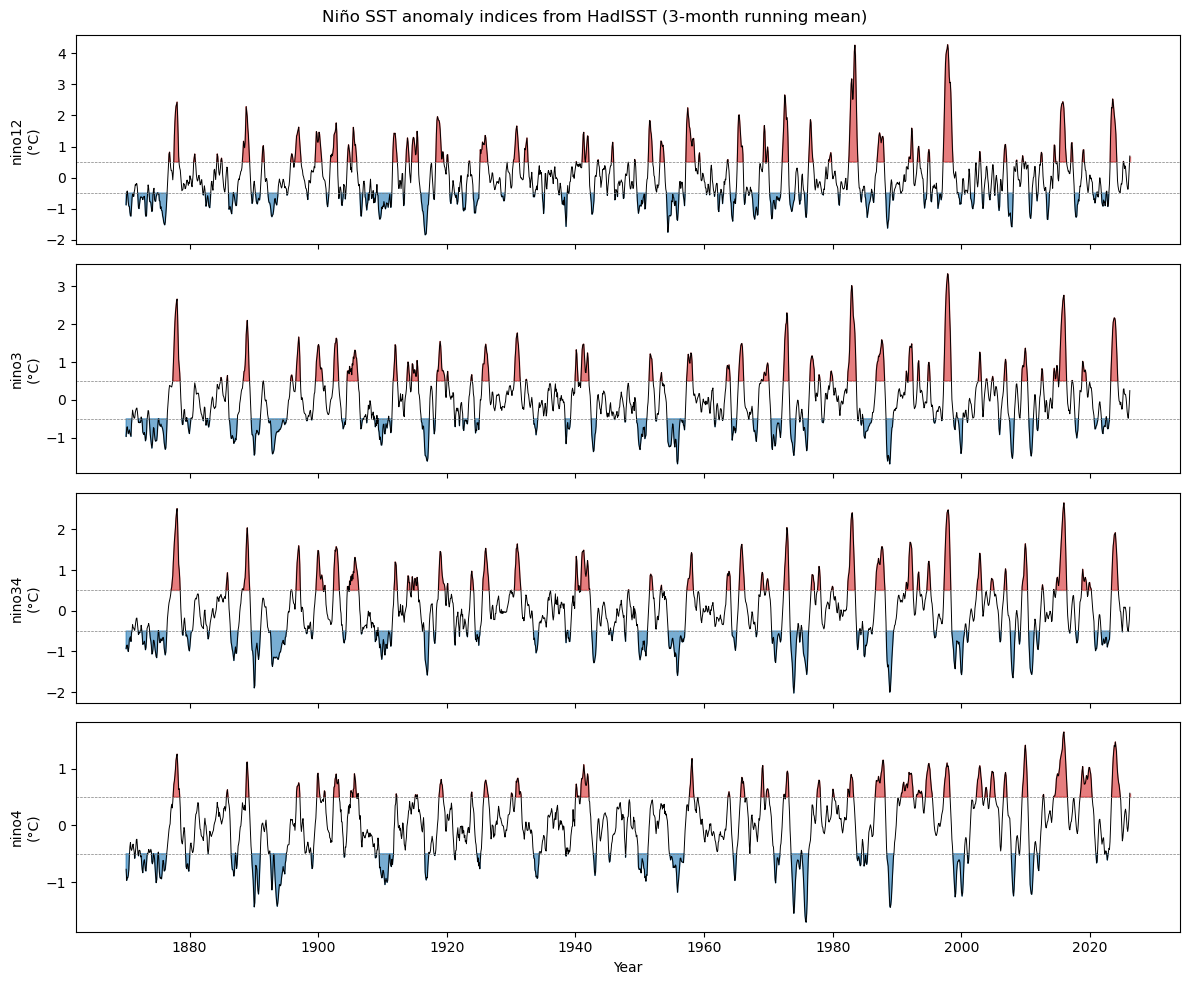

In [6]:
t = indices["time"].values

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
for ax, name in zip(axes, ["nino12", "nino3", "nino34", "nino4"]):
    y = indices[name].values
    ax.plot(t, y, color="black", lw=0.7)
    ax.fill_between(t, 0.5, y, where=(y >= 0.5), color="tab:red", alpha=0.6, interpolate=True)
    ax.fill_between(t, -0.5, y, where=(y <= -0.5), color="tab:blue", alpha=0.6, interpolate=True)
    ax.axhline(0.5, color="grey", lw=0.5, ls="--")
    ax.axhline(-0.5, color="grey", lw=0.5, ls="--")
    ax.set_ylabel(f"{name}\n(°C)")

axes[-1].set_xlabel("Year")
fig.suptitle("Niño SST anomaly indices from HadISST (3-month running mean)")
plt.tight_layout()
plt.show()

### Spatial patterns of El Niño and La Niña

The indices collapse the Pacific into a single number, but the events have a
distinctive spatial signature. Computing the full SST anomaly field and mapping a
strong El Niño against a strong La Niña shows the warm and cold "tongues" that
stretch along the equator.

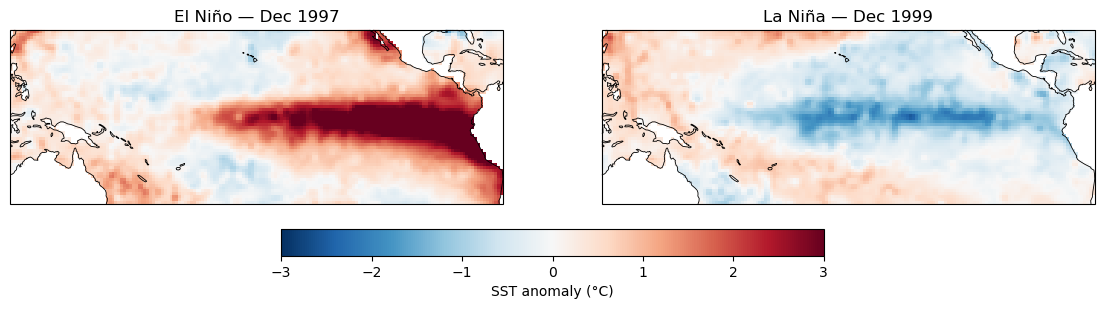

In [7]:
sst_clim = sst.groupby("time.month").mean("time")
sst_anom = sst.groupby("time.month") - sst_clim

elnino = sst_anom.sel(time="1997-12").squeeze()
lanina = sst_anom.sel(time="1999-12").squeeze()

proj = ccrs.PlateCarree(central_longitude=180)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), subplot_kw={"projection": proj})

for ax, field, label in zip(
    axes,
    [elnino, lanina],
    ["El Niño — Dec 1997", "La Niña — Dec 1999"],
):
    p = field.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        x="longitude",
        y="latitude",
        cmap="RdBu_r",
        vmin=-3,
        vmax=3,
        add_colorbar=False,
    )
    ax.coastlines(color="black", linewidth=0.6)
    ax.set_extent([120, 290, -30, 30], crs=ccrs.PlateCarree())
    ax.set_title(label)

fig.colorbar(p, ax=axes, orientation="horizontal", shrink=0.5, pad=0.08, label="SST anomaly (°C)")
plt.show()